In [146]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from datetime import timedelta
from xgboost import XGBClassifier
import os
from scipy.stats import entropy
from scipy.stats import uniform, randint

from sklearn.feature_selection import SelectFromModel
# !pip install imblearn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
# import warnings
# warnings.filterwarnings("ignore")

import sys
init_dir = os.getcwd()

In [147]:
consumer_df = pd.read_parquet('../mlc/training_data/consumer_data.parquet')
transactions = pd.read_parquet('../mlc/training_data/transactions.parquet')

In [148]:
consumer_df['evaluation_date'] = pd.to_datetime(consumer_df['evaluation_date'])
transactions['posted_date'] = pd.to_datetime(transactions['posted_date'])

In [149]:
consumer_df = consumer_df[consumer_df['masked_consumer_id'].str[2] == '1']
transactions = transactions[transactions['masked_consumer_id'].str[2] == '1']

In [150]:
# Step 1: Filter transactions to only those before or on the evaluation date
transactions_df = transactions.merge(
    consumer_df[['masked_consumer_id', 'evaluation_date']],
    on='masked_consumer_id',
    how='left'
)
transactions_df = transactions_df[transactions_df['posted_date'] < transactions_df['evaluation_date']]

In [177]:
# Cell 3: Train-validation split at consumer level
X_consumer = consumer_df.drop(columns='FPF_TARGET')
y_consumer = consumer_df['FPF_TARGET']

X_train_consumer, X_val_consumer, y_train, y_val = train_test_split(
    X_consumer, y_consumer,
    stratify=y_consumer,
    test_size=0.2,
    random_state=42
)

train_ids = X_train_consumer['masked_consumer_id']
val_ids = X_val_consumer['masked_consumer_id']


In [ ]:
# Cell 4: Feature engineering from transactions

def make_transaction_features(transactions, consumer_ids):
    subset = transactions[transactions['masked_consumer_id'].isin(consumer_ids)].copy()

    # Create debit/credit indicators
    subset['is_credit'] = subset['amount'] > 0
    subset['is_debit'] = subset['amount'] < 0

    # Basic aggregate features
    agg = subset.groupby('masked_consumer_id').agg(
        total_amount=('amount', 'sum'),
        mean_amount=('amount', 'mean'),
        std_amount=('amount', 'std'),
        min_amount=('amount', 'min'),
        max_amount=('amount', 'max'),
        median_amount=('amount', 'median'),
        transaction_count=('amount', 'count'),
        credit_sum=('is_credit', lambda x: subset.loc[x.index, 'amount'][x].sum()),
        debit_sum=('is_debit', lambda x: abs(subset.loc[x.index, 'amount'][x].sum()))
    )
    agg['credit_debit_ratio'] = agg['credit_sum'] / agg['debit_sum'].replace(0, np.nan)
    agg['credit_debit_ratio'] = agg['credit_debit_ratio'].fillna(0)

    # Recent 30-day features
    subset['days_before_eval'] = (subset['evaluation_date'] - subset['posted_date']).dt.days
    recent_df = subset[subset['days_before_eval'] <= 30].groupby('masked_consumer_id').agg(
        recent30_sum=('amount', 'sum'),
        recent30_count=('amount', 'count')
    )

    # Monthly volatility
    subset['month'] = subset['posted_date'].dt.to_period('M')
    monthly_cashflow = subset.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
    monthly_stats = monthly_cashflow.groupby('masked_consumer_id')['amount'].agg(['mean', 'std']).rename(
        columns={'mean': 'monthly_mean', 'std': 'monthly_std'})
    monthly_stats['monthly_cv'] = monthly_stats['monthly_std'] / monthly_stats['monthly_mean'].replace(0, np.nan) # coefficient of variation
    monthly_stats = monthly_stats.fillna(0)

    # Category encoding
    cat_encode = pd.get_dummies(subset, columns=['category'], drop_first=False)
    cat_cols = [col for col in cat_encode.columns if col.startswith('category_')]
    cat_encode_mean = cat_encode.groupby('masked_consumer_id')[cat_cols].sum()

    # Weekend spending
    subset['weekday'] = subset['posted_date'].dt.weekday
    subset['is_weekend'] = subset['weekday'] >= 5

    # Calculate weekend and weekday spending separately
    weekend_spend = subset[subset['amount'] > 0].groupby('masked_consumer_id').agg(
        weekday_spending=('amount', lambda x: x[~subset.loc[x.index, 'is_weekend']].sum()),
        weekend_spending=('amount', lambda x: x[subset.loc[x.index, 'is_weekend']].sum())
    )

    weekend_spend['weekend_ratio'] = weekend_spend['weekend_spending'] / (weekend_spend['weekday_spending'] + 1e-6)

    # Transaction frequency
    txn_freq = subset.groupby('masked_consumer_id').agg(
        unique_txn_days=('posted_date', lambda x: x.nunique()),
        txn_days_span=('posted_date', lambda x: (x.max() - x.min()).days + 1),
    )
    txn_freq['txn_per_day'] = txn_freq['unique_txn_days'] / txn_freq['txn_days_span'].replace(0, 1)

    # Percentiles
    percentiles = subset.groupby('masked_consumer_id')['amount'].quantile([0.25, 0.75, 0.9]).unstack()
    percentiles.columns = ['amount_25pct', 'amount_75pct', 'amount_90pct']

    # Large transactions
    subset['is_large'] = subset['amount'].abs() > 1000
    large_txns = subset.groupby('masked_consumer_id')['is_large'].sum().rename('large_txn_count')

    # Monthly trend
    monthly_spend = subset.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
    monthly_spend['month'] = monthly_spend['month'].dt.to_timestamp()

    def compute_monthly_trend(df):
        if df.shape[0] < 2:
            return 0
        df = df.sort_values('month')
        x = (df['month'] - df['month'].min()).dt.days.values.reshape(-1, 1)
        y = df['amount'].values
        model = LinearRegression().fit(x, y)
        return model.coef_[0]

    monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')

    # Merge all features
    features_df = agg \
        .join(recent_df, how='left') \
        .join(monthly_stats, how='left') \
        .join(cat_encode_mean, how='left') \
        .join(txn_freq, how='left') \
        .join(weekend_spend, how='left') \
        .join(large_txns, how='left') \
        .join(percentiles, how='left') \
        .join(monthly_trend, how='left') \
        .fillna(0) \
        .reset_index()

    return features_df

def make_weekly_category_features(transactions):
    tx = transactions.copy()
    tx['week'] = tx['posted_date'].dt.to_period('W').apply(lambda r: r.start_time)
    
    # Weekly sum and count by category
    weekly = tx.groupby(['masked_consumer_id', 'week', 'category'])['amount'].agg(['sum', 'count']).reset_index()
    
    # Weekly volatility across weeks, per user-category
    cat_volatility = weekly.groupby(['masked_consumer_id', 'category'])['sum'].agg(['std', 'mean'])
    cat_volatility['cv'] = cat_volatility['std'] / cat_volatility['mean'].replace(0, np.nan)
    cat_volatility = cat_volatility.unstack().fillna(0)
    cat_volatility.columns = [f'weekly_cat_{stat}_{int(cat)}' for stat, cat in cat_volatility.columns]

    # Category trend over weeks (linear regression slope of weekly sum)
    def compute_weekly_trend(df):
        if df.shape[0] < 2:
            return 0
        df = df.sort_values('week')
        x = (df['week'] - df['week'].min()).dt.days.values.reshape(-1, 1)
        y = df['sum'].values
        model = LinearRegression().fit(x, y)
        return model.coef_[0]

    cat_trends = weekly.groupby(['masked_consumer_id', 'category']).apply(compute_weekly_trend).unstack().fillna(0)
    cat_trends.columns = [f'weekly_trend_cat_{int(c)}' for c in cat_trends.columns]

    # Combine all
    weekly_cat_feats = cat_volatility.join(cat_trends)
    weekly_cat_feats = weekly_cat_feats.reset_index()

    return weekly_cat_feats


# X_train_txn = make_transaction_features(transactions_df, train_ids)
# X_val_txn = make_transaction_features(transactions_df, val_ids)

def make_transaction_features_with_weekly(transactions, consumer_ids):
    base_feats = make_transaction_features(transactions, consumer_ids)
    weekly_feats = make_weekly_category_features(transactions[transactions['masked_consumer_id'].isin(consumer_ids)])
    final = base_feats.merge(weekly_feats, on='masked_consumer_id', how='left').fillna(0)
    return final

X_train_txn = make_transaction_features_with_weekly(transactions_df, train_ids)
X_val_txn = make_transaction_features_with_weekly(transactions_df, val_ids)


/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_12536/1876682386.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')
/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_12536/1876682386.py:125: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_trends = weekly.groupby(['ma

In [354]:
# Cell 5: Merge transaction features into consumer-level data
X_train = X_train_consumer.merge(X_train_txn, on='masked_consumer_id', how='left')
X_val = X_val_consumer.merge(X_val_txn, on='masked_consumer_id', how='left')

# Drop identifier
X_train = X_train.drop(columns=['masked_consumer_id', 'evaluation_date']).fillna(0)
X_val = X_val.drop(columns=['masked_consumer_id', 'evaluation_date']).fillna(0)


In [460]:
pd.set_option('display.max_columns', None)
X_train.columns.to_list()

['total_balance',
 'total_amount',
 'mean_amount',
 'std_amount',
 'min_amount',
 'max_amount',
 'median_amount',
 'transaction_count',
 'credit_sum',
 'debit_sum',
 'credit_debit_ratio',
 'recent30_sum',
 'recent30_count',
 'monthly_mean',
 'monthly_std',
 'monthly_cv',
 'category_0.0',
 'category_1.0',
 'category_2.0',
 'category_3.0',
 'category_4.0',
 'category_5.0',
 'category_6.0',
 'category_7.0',
 'category_8.0',
 'category_9.0',
 'category_10.0',
 'category_11.0',
 'category_12.0',
 'category_13.0',
 'category_14.0',
 'category_15.0',
 'category_16.0',
 'category_17.0',
 'category_18.0',
 'category_19.0',
 'category_20.0',
 'category_21.0',
 'category_22.0',
 'category_23.0',
 'category_24.0',
 'category_25.0',
 'category_26.0',
 'category_27.0',
 'category_28.0',
 'category_29.0',
 'category_30.0',
 'category_31.0',
 'category_32.0',
 'category_33.0',
 'category_34.0',
 'category_35.0',
 'unique_txn_days',
 'txn_days_span',
 'txn_per_day',
 'weekday_spending',
 'weekend_spend

In [410]:
pd.set_option('display.max_columns', None)
cat_cols = [col for col in X_train.columns if col.startswith('category_')]
X_train

,total_balance,total_amount,mean_amount,std_amount,min_amount,max_amount,median_amount,transaction_count,credit_sum,debit_sum,credit_debit_ratio,recent30_sum,recent30_count,monthly_mean,monthly_std,monthly_cv,category_0.0,category_1.0,category_2.0,category_3.0,category_4.0,category_5.0,category_6.0,category_7.0,category_8.0,category_9.0,category_10.0,category_11.0,category_12.0,category_13.0,category_14.0,category_15.0,category_16.0,category_17.0,category_18.0,category_19.0,category_20.0,category_21.0,category_22.0,category_23.0,category_24.0,category_25.0,category_26.0,category_27.0,category_28.0,category_29.0,category_30.0,category_31.0,category_32.0,category_33.0,category_34.0,category_35.0,unique_txn_days,txn_days_span,txn_per_day,weekday_spending,weekend_spending,weekend_ratio,large_txn_count,amount_25pct,amount_75pct,amount_90pct,monthly_spend_trend,weekly_cat_std_0,weekly_cat_std_1,weekly_cat_std_2,weekly_cat_std_3,weekly_cat_std_4,weekly_cat_std_5,weekly_cat_std_6,weekly_cat_std_7,weekly_cat_std_8,weekly_cat_std_9,weekly_cat_std_10,weekly_cat_std_11,weekly_cat_std_12,weekly_cat_std_13,weekly_cat_std_14,weekly_cat_std_15,weekly_cat_std_16,weekly_cat_std_17,weekly_cat_std_18,weekly_cat_std_19,weekly_cat_std_20,weekly_cat_std_21,weekly_cat_std_22,weekly_cat_std_23,weekly_cat_std_24,weekly_cat_std_25,weekly_cat_std_26,weekly_cat_std_27,weekly_cat_std_28,weekly_cat_std_29,weekly_cat_std_30,weekly_cat_std_31,weekly_cat_std_32,weekly_cat_std_33,weekly_cat_std_34,weekly_cat_std_35,weekly_cat_mean_0,weekly_cat_mean_1,weekly_cat_mean_2,weekly_cat_mean_3,weekly_cat_mean_4,weekly_cat_mean_5,weekly_cat_mean_6,weekly_cat_mean_7,weekly_cat_mean_8,weekly_cat_mean_9,weekly_cat_mean_10,weekly_cat_mean_11,weekly_cat_mean_12,weekly_cat_mean_13,weekly_cat_mean_14,weekly_cat_mean_15,weekly_cat_mean_16,weekly_cat_mean_17,weekly_cat_mean_18,weekly_cat_mean_19,weekly_cat_mean_20,weekly_cat_mean_21,weekly_cat_mean_22,weekly_cat_mean_23,weekly_cat_mean_24,weekly_cat_mean_25,weekly_cat_mean_26,weekly_cat_mean_27,weekly_cat_mean_28,weekly_cat_mean_29,weekly_cat_mean_30,weekly_cat_mean_31,weekly_cat_mean_32,weekly_cat_mean_33,weekly_cat_mean_34,weekly_cat_mean_35,weekly_cat_cv_0,weekly_cat_cv_1,weekly_cat_cv_2,weekly_cat_cv_3,weekly_cat_cv_4,weekly_cat_cv_5,weekly_cat_cv_6,weekly_cat_cv_7,weekly_cat_cv_8,weekly_cat_cv_9,weekly_cat_cv_10,weekly_cat_cv_11,weekly_cat_cv_12,weekly_cat_cv_13,weekly_cat_cv_14,weekly_cat_cv_15,weekly_cat_cv_16,weekly_cat_cv_17,weekly_cat_cv_18,weekly_cat_cv_19,weekly_cat_cv_20,weekly_cat_cv_21,weekly_cat_cv_22,weekly_cat_cv_23,weekly_cat_cv_24,weekly_cat_cv_25,weekly_cat_cv_26,weekly_cat_cv_27,weekly_cat_cv_28,weekly_cat_cv_29,weekly_cat_cv_30,weekly_cat_cv_31,weekly_cat_cv_32,weekly_cat_cv_33,weekly_cat_cv_34,weekly_cat_cv_35,weekly_trend_cat_0,weekly_trend_cat_1,weekly_trend_cat_2,weekly_trend_cat_3,weekly_trend_cat_4,weekly_trend_cat_5,weekly_trend_cat_6,weekly_trend_cat_7,weekly_trend_cat_8,weekly_trend_cat_9,weekly_trend_cat_10,weekly_trend_cat_11,weekly_trend_cat_12,weekly_trend_cat_13,weekly_trend_cat_14,weekly_trend_cat_15,weekly_trend_cat_16,weekly_trend_cat_17,weekly_trend_cat_18,weekly_trend_cat_19,weekly_trend_cat_20,weekly_trend_cat_21,weekly_trend_cat_22,weekly_trend_cat_23,weekly_trend_cat_24,weekly_trend_cat_25,weekly_trend_cat_26,weekly_trend_cat_27,weekly_trend_cat_28,weekly_trend_cat_29,weekly_trend_cat_30,weekly_trend_cat_31,weekly_trend_cat_32,weekly_trend_cat_33,weekly_trend_cat_34,weekly_trend_cat_35
0,20312.17,19363.50,81.359244,1321.435222,-1681.77,19000.0,-19.95,238.0,38298.61,18935.11,2.022624,17855.18,71.0,4840.875000,7870.041786,1.625748,0.0,40.0,0.0,0.0,13.0,6.0,0.0,2.0,0.0,0.0,0.0,1.0,4.0,0.0,62.0,13.0,39.0,5.0,6.0,3.0,6.0,2.0,17.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,57.0,85.0,0.670588,38298.61,0.00,0.00000,10.0,-52.630,-5.00,0.010,139.686763,0.000000,174.342007,0.000000,0.000000,361.037400,14.326597,0.000000,0.000000,0.000000,0.0,0.0,0.000000,10340.885000,0.000000,73.507617,

In [451]:
from sklearn.feature_selection import mutual_info_classif, f_classif

# Mutual information (non-linear associations)
mi_scores = mutual_info_classif(X_train, y_train)

# ANOVA F-test (linear discrimination)
f_scores = f_classif(X_train, y_train)[0]
print('MI scores:', mi_scores)
print('F-scores:', f_scores)

MI scores: [2.66067092e-03 4.49981041e-03 6.03359506e-04 0.00000000e+00
 0.00000000e+00 1.95239969e-03 3.39832392e-03 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.87632737e-03
 0.00000000e+00 5.68020121e-04 1.85008752e-03 6.21484504e-03
 5.75314255e-04 0.00000000e+00 0.00000000e+00 1.19548981e-03
 0.00000000e+00 8.40212833e-04 1.48561820e-05 1.95750475e-03
 1.34542964e-03 3.33279198e-04 0.00000000e+00 6.12057223e-04
 2.76001693e-03 3.19458845e-03 6.33107742e-04 0.00000000e+00
 1.80701888e-03 0.00000000e+00 0.00000000e+00 1.19818830e-03
 1.84898270e-03 0.00000000e+00 4.80941009e-03 1.32090409e-03
 0.00000000e+00 0.00000000e+00 3.84534223e-03 2.50294425e-03
 0.00000000e+00 2.89127338e-03 1.08704157e-03 6.12866284e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.69827455e-03 1.30830782e-03 6.37502164e-04 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.27758161e-04 2.63187153e-04
 0.00000000e+00 0.00000000e+00 2.65220862e-03 1.77401209e-03
 1.23196480e-


Top 10 features by Mutual Information:
                feature  mi_score   f_score
15           monthly_cv  0.006215  0.006306
110  weekly_cat_mean_11  0.005208  0.095324
38        category_22.0  0.004809  1.383839
120  weekly_cat_mean_21  0.004656  0.491101
176  weekly_trend_cat_5  0.004607  0.042191
1          total_amount  0.004500  0.848921
76    weekly_cat_std_13  0.004313  0.638687
180  weekly_trend_cat_9  0.004196  0.017070
42        category_26.0  0.003845  9.416513
81    weekly_cat_std_18  0.003716  4.202380

Top 10 features by F-score:
                 feature  mi_score    f_score
153     weekly_cat_cv_18  0.003302  17.073356
186  weekly_trend_cat_15  0.000000  14.047422
161     weekly_cat_cv_26  0.002132  13.732740
61          amount_90pct  0.000000   9.824809
42         category_26.0  0.003845   9.416513
37         category_21.0  0.000000   8.107008
89     weekly_cat_std_26  0.003304   6.593954
28         category_12.0  0.002760   5.968790
200  weekly_trend_cat_29  0.00023

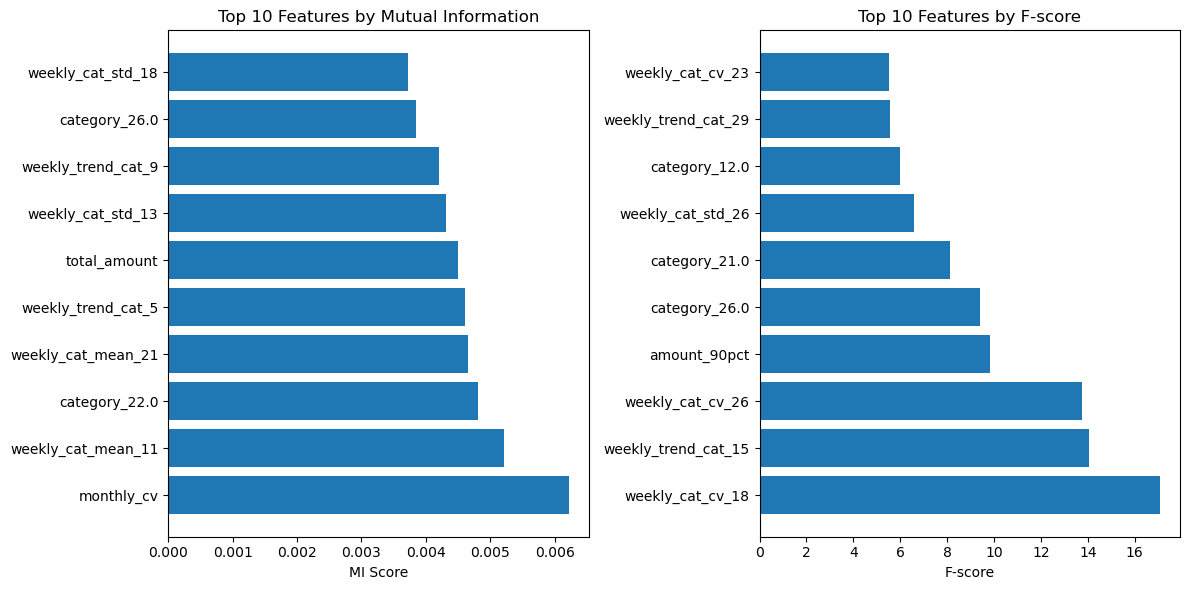

In [452]:
# Create a DataFrame to compare both scores
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'mi_score': mi_scores,
    'f_score': f_scores
})

# Sort by each score to see top features
print("\nTop 10 features by Mutual Information:")
print(feature_importance.sort_values('mi_score', ascending=False).head(10))

print("\nTop 10 features by F-score:")
print(feature_importance.sort_values('f_score', ascending=False).head(10))

# Visualize the scores
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(feature_importance.sort_values('mi_score', ascending=False)['feature'][:10],
         feature_importance.sort_values('mi_score', ascending=False)['mi_score'][:10])
plt.title('Top 10 Features by Mutual Information')
plt.xlabel('MI Score')

plt.subplot(1, 2, 2)
plt.barh(feature_importance.sort_values('f_score', ascending=False)['feature'][:10],
         feature_importance.sort_values('f_score', ascending=False)['f_score'][:10])
plt.title('Top 10 Features by F-score')
plt.xlabel('F-score')
plt.tight_layout()
plt.show()

In [454]:
# Use SelectKBest to select top features
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 20 features
selector = SelectKBest(f_classif, k=20)
X_train_selected = selector.fit_transform(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()].tolist()
print("Selected features:", selected_features)

Selected features: ['category_12.0', 'category_21.0', 'category_26.0', 'category_34.0', 'amount_90pct', 'weekly_cat_std_18', 'weekly_cat_std_21', 'weekly_cat_std_26', 'weekly_cat_mean_1', 'weekly_cat_mean_26', 'weekly_cat_cv_18', 'weekly_cat_cv_23', 'weekly_cat_cv_24', 'weekly_cat_cv_25', 'weekly_cat_cv_26', 'weekly_trend_cat_12', 'weekly_trend_cat_15', 'weekly_trend_cat_18', 'weekly_trend_cat_21', 'weekly_trend_cat_29']


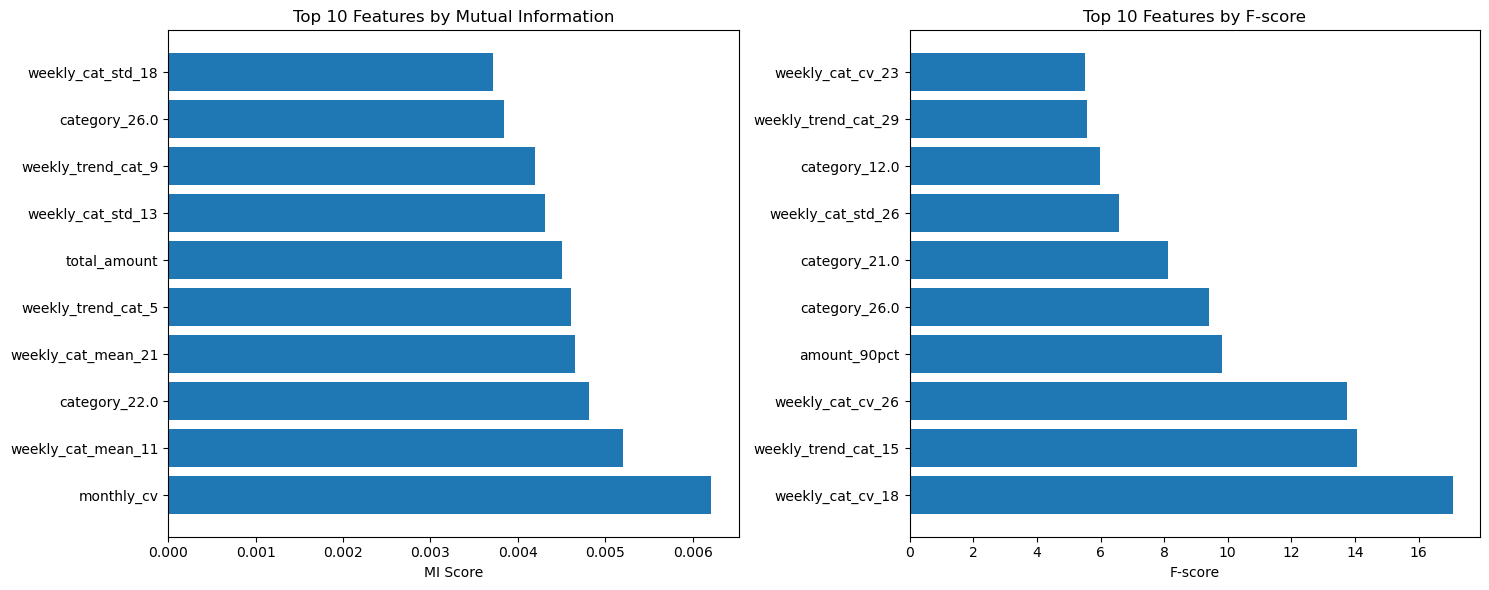

In [455]:
# Create a more informative visualization
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.barh(feature_importance.sort_values('mi_score', ascending=False)['feature'][:10],
         feature_importance.sort_values('mi_score', ascending=False)['mi_score'][:10])
plt.title('Top 10 Features by Mutual Information')
plt.xlabel('MI Score')

plt.subplot(1, 2, 2)
plt.barh(feature_importance.sort_values('f_score', ascending=False)['feature'][:10],
         feature_importance.sort_values('f_score', ascending=False)['f_score'][:10])
plt.title('Top 10 Features by F-score')
plt.xlabel('F-score')
plt.tight_layout()
plt.show()

In [456]:
# Check class distribution
print("Class distribution:", y_train.value_counts(normalize=True))

# If imbalanced, use class weights
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
f_scores = f_classif(X_train, y_train)[0]

Class distribution: FPF_TARGET
0.0    0.985625
1.0    0.014375
Name: proportion, dtype: float64


In [453]:
# Check correlation between features
correlation_matrix = X_train.corr()
high_correlation = np.where(np.abs(correlation_matrix) > 0.8)
high_correlation = [(correlation_matrix.index[x], correlation_matrix.columns[y], correlation_matrix.iloc[x, y]) 
                    for x, y in zip(*high_correlation) if x != y and x < y]
print("Highly correlated features:", high_correlation)

Highly correlated features: [('total_amount', 'monthly_mean', 0.9467211066588873), ('mean_amount', 'weekly_trend_cat_19', -0.8309748369333996), ('std_amount', 'min_amount', -0.8569386619509854), ('std_amount', 'max_amount', 0.813444459401528), ('min_amount', 'max_amount', -0.8996955200755135), ('transaction_count', 'recent30_count', 0.8342894975854088), ('credit_sum', 'debit_sum', 0.9901240446896781), ('credit_sum', 'weekday_spending', 0.9996652738444176), ('debit_sum', 'weekday_spending', 0.9897380190494085), ('weekly_cat_std_2', 'weekly_cat_mean_2', 0.9107912681443578), ('weekly_cat_std_3', 'weekly_cat_mean_3', 0.8417454675419637), ('weekly_cat_std_4', 'weekly_cat_mean_4', 0.8806652265060764), ('weekly_cat_std_9', 'weekly_cat_cv_9', 0.8386428623346519), ('weekly_cat_std_14', 'weekly_cat_mean_14', -0.9366900122487575), ('weekly_cat_std_15', 'weekly_cat_mean_15', -0.9730908436284418), ('weekly_cat_std_15', 'weekly_trend_cat_15', -0.8073727306197048), ('weekly_cat_std_18', 'weekly_cat_m

In [446]:
from sklearn.model_selection import StratifiedKFold

importances = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_train, y_train):
    model = XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42,  max_depth = 3)
    model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    importances.append(model.feature_importances_)

mean_importance = np.mean(importances, axis=0)
std_importance = np.std(importances, axis=0)
features = X_train.columns
mean_importance
features_df = pd.DataFrame({
    'feature': features,
    'importance': mean_importance,
    'std': std_importance
})  
features_df_sorted =features_df.sort_values('importance', ascending=False)
features_lst = features_df_sorted['feature'].head(100).to_numpy()
features_lst
# features_df

array(['category_26.0', 'category_22.0', 'weekly_cat_cv_26',
       'weekly_cat_mean_4', 'weekly_cat_mean_26', 'weekly_cat_std_18',
       'category_23.0', 'weekly_cat_mean_23', 'credit_debit_ratio',
       'weekly_cat_std_4', 'weekly_cat_cv_18', 'monthly_std',
       'weekly_cat_mean_12', 'category_12.0', 'weekly_cat_mean_16',
       'weekly_trend_cat_18', 'weekly_cat_std_27', 'weekly_cat_std_12',
       'weekly_cat_mean_1', 'category_27.0', 'weekly_trend_cat_23',
       'unique_txn_days', 'weekly_cat_std_23', 'weekly_cat_mean_7',
       'total_balance', 'weekly_cat_std_26', 'weekly_cat_cv_1',
       'category_2.0', 'weekly_trend_cat_1', 'weekly_cat_cv_7',
       'weekly_cat_std_16', 'monthly_spend_trend', 'txn_per_day',
       'weekly_trend_cat_7', 'weekly_cat_mean_28', 'total_amount',
       'weekly_cat_cv_23', 'weekly_trend_cat_17', 'weekly_cat_mean_27',
       'category_21.0', 'weekly_trend_cat_26', 'category_19.0',
       'weekly_cat_mean_14', 'weekly_cat_std_6', 'weekly_cat_std_

In [449]:
features_df_sorted.head(100)

,feature,importance,std
42,category_26.0,0.018647,0.010882
38,category_22.0,0.017336,0.011707
161,weekly_cat_cv_26,0.016884,0.003196
103,weekly_cat_mean_4,0.016570,0.006074
125,weekly_cat_mean_26,0.016497,0.004981
...,...,...,...
139,weekly_cat_cv_4,0.004367,0.003883
13,monthly_mean,0.004344,0.003788
12,recent30_count,0.004187,0.003903
112,weekly_cat_mean_13,0.003932,0.003339


In [447]:
features_df.describe()

,importance,std
count,207.000000,207.000000
mean,0.004831,0.003035
std,0.004638,0.002449
min,0.000000,0.000000
25%,0.000868,0.000797
50%,0.003512,0.003138
75%,0.007279,0.004365
max,0.018647,0.013133


In [430]:
# Cell 6: Lasso + SMOTE + Logistic Regression pipeline
# pipeline = ImbPipeline(steps=[
#     ('scaler', StandardScaler()),  # normalize
#     ('smote', SMOTE(random_state=42)),  # balance classes
#     # ('feature_select', SelectFromModel(LogisticRegression(
#     #     penalty='l1', C=0.01, solver='saga', class_weight='balanced', random_state=42, max_iter=1000))),
#     # ('model', LogisticRegression(
#     #     penalty='l2', C=0.01, solver='saga', class_weight='balanced', random_state=42, max_iter=1000)),
#     ('model', XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42))
# ])
pipeline = Pipeline([
    ('model', XGBClassifier(
        # n_estimators=100,
        # learning_rate=0.05,
        # max_depth=3,
        # eval_metric='auc',
        # random_state=42
    ))
])
# neg, pos = np.bincount(y_train)
# scale = neg / pos  # e.g., if 99% zeros, scale ≈ 99
# print(scale)
# # 2. Define pipeline with XGBoost + scale_pos_weight
# pipeline = ImbPipeline(steps=[
#     ('scaler', StandardScaler()),
#     ('smote', SMOTE(random_state=42)),  # you can also remove this to let scale_pos_weight do the job alone
#     ('model', XGBClassifier(
#         use_label_encoder=False,
#         eval_metric='auc',
#         random_state=42,
#         scale_pos_weight=scale
#     ))
# ])

# pipeline = Pipeline([
#     ('model', XGBClassifier(n_estimators=400, learning_rate=0.05, random_state=42,  max_depth = 3))
# ])

# pipeline = Pipeline([
#     ('model', XGBClassifier(eval_metric='auc', use_label_encoder=False, random_state=42))
# ])

param_dist = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma': [0, 1, 3]
}
# param_dist = {
#     'model__n_estimators': randint(100, 500),
#     'model__learning_rate': uniform(0.01, 0.2),
#     'model__max_depth': randint(3, 10),
# }

# # Randomized search
# search = RandomizedSearchCV(
#     pipeline,
#     param_distributions=param_distributions,
#     n_iter=50,
#     scoring='roc_auc',
#     n_jobs=-1,
#     cv=3,
#     random_state=42,
#     verbose=1
# )

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    scoring='roc_auc',
    n_iter=30,  # tune as needed
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search = pipeline



In [396]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_xgb_feature_importance(xgb_model, feature_names, top_n=20, importance_type='gain'):
    """
    Plot top N XGBoost feature importances using the specified importance type.
    
    Parameters:
    - xgb_model: fitted XGBClassifier
    - feature_names: list of column names
    - top_n: number of top features to show
    - importance_type: 'weight', 'gain', 'cover', 'total_gain', or 'total_cover'
    """
    booster = xgb_model.get_booster()
    importance = booster.get_score(importance_type=importance_type)
    importance_df = pd.DataFrame({
        'feature': list(importance.keys()),
        'importance': list(importance.values())
    })

    # Align with original feature names (in case of preprocessing)
    importance_df['feature'] = importance_df['feature'].map(lambda x: feature_names[int(x[1:])] if x.startswith('f') else x)

    top_features = importance_df.sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=top_features)
    plt.title(f'Top {top_n} XGBoost Features ({importance_type})')
    plt.tight_layout()
    plt.show()


In [397]:
X_train.columns.shape

(207,)

In [409]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(X_train)
X_filtered

array([[ 2.03121700e+04,  1.93635000e+04,  8.13592437e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 7.40918800e+04,  2.99022900e+04,  2.27740213e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.63945000e+03,  1.10973000e+03,  2.08204503e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 1.25805000e+03, -6.94302000e+03, -2.94195763e+01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 3.05172000e+03, -5.47130000e+02, -5.15673893e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.36425000e+03, -1.17534000e+03, -1.76742857e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [445]:
# Cell 7: Fit model and evaluate
search.fit(X_train[features_lst], y_train)

y_val_proba = search.predict_proba(X_val[features_lst])[:, 1]
val_auc = roc_auc_score(y_val, y_val_proba)
# print(f"Best CV AUC: {search.best_score_:.4f}")
print(f"Validation AUC: {val_auc:.4f}")
# print("Best parameters:", search.best_params_)
# print(classification_report(y_val, y_val_proba > 0.01))
# plot_xgb_feature_importance(search.best_estimator_.named_steps['model'], feature_names=X_train.columns)

Validation AUC: 0.7122


In [435]:
# pipeline_lr = ImbPipeline([
#     ('scaler', StandardScaler()),
#     # ('smote', SMOTE(random_state=42)),
#     # ('model', LogisticRegression(penalty='l2', class_weight='balanced', max_iter=1000)),
#     ('model', LogisticRegression(penalty='l2', max_iter=1000))
# ])
# pipeline_lr.fit(X_train[features_lst], y_train)

# y_val_proba_lr = pipeline_lr.predict_proba(X_val[features_lst])[:, 1]
# val_auc_lr = roc_auc_score(y_val, y_val_proba_lr) 
# print(f"Validation AUC: {val_auc_lr:.4f}")

Validation AUC: 0.6385


In [434]:
# Step 1: Fit plain XGBoost model
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

# Step 2: Get top N important features
booster = xgb_model.get_booster()
score_dict = booster.get_score(importance_type='gain')
sorted_feats = sorted(score_dict.items(), key=lambda x: x[1], reverse=True)
top_feats = [f[0] for f in sorted_feats[:30]]  # top 30 features

# Map feature names (f0, f1, ...) back to column names
# feat_map = {f'f{i}': name for i, name in enumerate(X_train.columns)}
selected_features = top_feats

# Step 3: Subset your data and fit LR
X_train_lr = X_train[selected_features]
X_val_lr = X_val[selected_features]

pipeline_lr = ImbPipeline([
    ('scaler', StandardScaler()),
    # ('smote', SMOTE(random_state=42)),
    # ('model', LogisticRegression(penalty='l2', class_weight='balanced', max_iter=1000)),
    ('model', LogisticRegression(penalty='l2', max_iter=1000))
])
pipeline_lr.fit(X_train_lr, y_train)

y_val_proba_lr = pipeline_lr.predict_proba(X_val_lr)[:, 1]
val_auc_lr = roc_auc_score(y_val, y_val_proba_lr) 
print(f"Validation AUC: {val_auc_lr:.4f}")

Validation AUC: 0.6779


In [400]:
X_train_lr

,weekly_cat_std_23,category_22.0,weekly_trend_cat_23,total_amount,transaction_count,weekly_cat_std_17,weekly_cat_std_1,monthly_std,weekly_trend_cat_18,weekly_cat_cv_18,weekly_cat_std_27,weekly_cat_mean_26,weekly_cat_cv_26,weekly_cat_mean_18,weekly_cat_mean_24,weekly_trend_cat_26,large_txn_count,monthly_spend_trend,category_21.0,category_26.0,weekly_cat_std_30,weekly_cat_cv_24,weekly_cat_mean_12,weekly_cat_mean_1,debit_sum,weekly_cat_mean_5,unique_txn_days,category_23.0,credit_debit_ratio,category_13.0
0,0.000000,17.0,0.000000,19363.50,238.0,10.448907,174.342007,7870.041786,0.566361,-0.528572,6.261971,-685.714286,-0.213478,-52.078000,0.000000,-2.280551,10.0,139.686763,2.0,8.0,0.000000,0.000000,3488.672500,-54.256667,18935.11,2554.091667,57.0,0.0,2.022624,0.0
1,0.000000,42.0,0.000000,29902.29,1313.0,57.767938,1218.253799,3266.571439,0.196869,-0.534697,35.173381,-971.493542,-1.155642,-173.969216,-9.980000,-3.254785,73.0,5.470217,62.0,115.0,89.332227,0.000000,-50.000000,-828.898077,163256.89,768.383333,245.0,0.0,1.183161,15.0
2,0.994786,62.0,-0.002264,1109.73,533.0,76.025387,93.593179,1609.945059,0.043030,-0.728539,22.757840,-409.834615,-1.527082,-49.820400,0.000000,-1.776498,21.0,-1.988605,6.0,14.0,0.000000,0.000000,-1067.076923,-89.804286,42681.04,0.000000,238.0,25.0,1.026001,1.0
3,22.775931,51.0,0.025509,-113.91,1363.0,15.651748,255.521118,1577.629761,-0.104232,-0.779335,46.138578,-670.153784,-3.710612,-114.776047,-24.156000,-1.375680,57.0,-2.403630,0.0,62.0,0.000000,-0.386765,-155.344516,-157.562381,104499.85,0.000000,246.0,13.0,0.998910,21.0
4,20.880613,41.0,0.234333,1.39,1489.0,52.733802,432.080826,1167.987316,0.026179,-0.508573,301.694847,-1046.577000,-2.901465,-142.148837,-41.970000,-11.534602,45.0,0.159975,40.0,30.0,0.000000,0.000000,179.253333,-174.719714,119647.39,2437.293333,210.0,4.0,1.000012,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,10.451874,30.0,0.052548,-37739.49,1440.0,529.147505,2310.347976,5654.811030,0.077936,-0.720802,45.448142,-202.130000,-1.025818,-225.103600,-116.190000,0.061977,60.0,28.805026,189.0,96.0,0.000000,-0.345159,-850.827692,-816.890370,186360.59,12.266667,242.0,6.0,0.797492,1.0
3196,7.394255,56.0,-0.011268,5165.06,1864.0,412.392254,2535.378610,4496.184554,0.259485,-0.573725,105.344645,-2314.838000,-1.645504,-219.342653,-115.753750,-7.994892,144.0,-7.908159,66.0,109.0,0.000000,-0.745661,-1713.326667,-207.253077,329257.13,0.000000,250.0,5.0,1.015687,4.0
3197,0.000000,11.0,0.000000,-6943.02,236.0,165.931529,995.638382,3602.035474,0.000000,0.000000,0.000000,-1211.700000,-1.005316,0.000000,0.000000,-2.706690,65.0,-1.195163,0.0,60.0,0.000000,0.000000,-1128.068125,511.380000,117018.57,0.000000,131.0,0.0,0.940667,3.0
3198,13.539337,2.0,0.032420,-547.13,1061.0,428.373819,1023.845220,3165.313018,0.037380,-0.681072,33.345890,-1419.758857,-0.999801,-338.464894,-30.853333,-1.000893,94.0,-2.986449,1.0,59.0,283.090200,-0.110625,-874.193529,475.091538,178077.30,2435.153462,231.0,13.0,0.996928,12.0


Model Parameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'auc', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': False}

Top 10 Most Important Features:
 

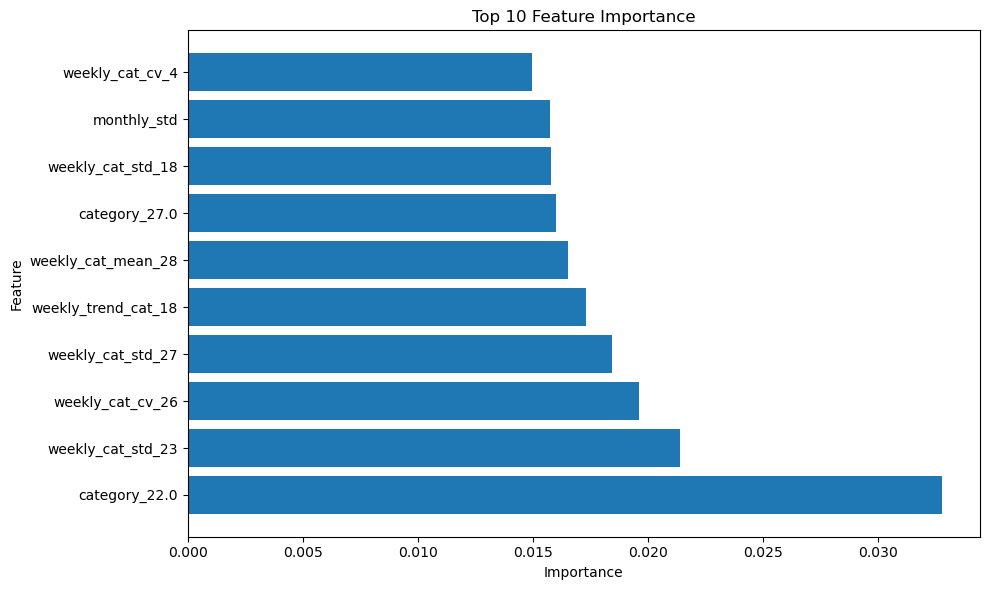

In [401]:
# 1. Get the model from the pipeline
model = search.named_steps['model']

# 2. Get model parameters
print("Model Parameters:")
print(model.get_params())

# 3. Get feature importance
# For XGBoost, you can get feature importance in different ways:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,  # Make sure X_train has the same columns as your training data
    'importance': model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Display top features
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Optional: Visualize feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [402]:
# from sklearn.metrics import precision_recall_curve

# prec, rec, thresholds = precision_recall_curve(y_val, y_val_proba)
# for t, p, r in zip(thresholds[::20], prec[::20], rec[::20]):
#     print(f"Threshold: {t:.2f}, Precision: {p:.2f}, Recall: {r:.2f}")


In [403]:
# import matplotlib.pyplot as plt

# plt.hist(y_val_proba[y_val == 1], bins=30, alpha=0.6, label='Positive')
# plt.hist(y_val_proba[y_val == 0], bins=30, alpha=0.6, label='Negative')
# plt.axvline(0.5, color='red', linestyle='--')
# plt.legend()
# plt.title("Validation prediction probabilities")
# plt.show()


In [433]:
y_train_pred_proba = search.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, y_train_pred_proba)

print("Training AUC:", train_auc)

Training AUC: 1.0


In [405]:
# Cell 8 (Optional): Get selected features
# mask = pipeline.named_steps['feature_select'].get_support()
# selected_features = X_train.columns[mask]
# print("Selected features:", selected_features.tolist())


In [406]:
# mask.sum()